# Chapter 06 비지도 학습
## 06-3 주성분 분석
### 차원과 차원 축소
* 지금까지 우리는 데이터가 가진 속성을 특성이라 불렀음. 과일 사진의 경우 10,000개의 픽셀이 있기 때문에 10,000개의 특성이 있는 셈. 머신러닝에서는 이런 특성을 **차원dimension**이라고 부름. 10,000개의 특성은 결국 10,000개의 차원이라는 건데 이 차원을 줄일 수 있다면 저장 공간을 크게 절약할 수 있을 것.
> 2차원 배열과 1차원 배열의 차원은 다른 건가요?
> * 2차원 배열과 1차원 배열(벡터)에서 차원이란 용어는 조금 다르게 사용함. 다차원 배열에서 차원은 배열의 축 개수가 됨. 가령 2차원 배열일 때는 행과 열이 차원이 됨. 하지만 1차원 배열, 즉 벡터일 경우에는 원소의 개수를 말함.
> * 이 절에서는 혼돈을 피하고자 가능하면 차원 대신 특성을 사용함. 하지만 차원이란 단어를 완전히 배제하기는 어려움.
* 이를 위해 비지도 학습 작업 중 하나인 **차원 축소dimensionality reduction** 알고리즘을 다루어 보겠음. 3장에서 특성이 많으면 선형 모델의 성능이 높아지고 훈련 데이터에 쉽게 과대적합된다는 것을 배웠음. 차원 축소는 데이터를 가장 잘 나타내는 일부 특성을 선택하여 데이터 크기를 줄이고 지도 학습 모델의 성능을 향상시킬 수 있는 방법.
* 또한 줄어든 차원에서 다시 원본 차원(예를 들어 과일 사진의 경우 10,000개의 차원)으로 손실을 최대한 줄이면서 복원할 수도 있음. 이 절에서는 대표적인 차원 축소 알고리즘은 **주성분 분석principal component analysis**을 배우겠음. 주성분 분석을 간단히 **PCA**라고도 부름.

### 주성분 분석 소개
* 주성분 분석PCA은 데이터에 있는 분산이 큰 방향을 찾는 것으로 이해할 수 있음. 분산은 데이터가 널리 퍼져있는 정도를 말함. 분산이 큰 방향이란 데이터를 잘 표현하는 어떤 벡터라고 생각할 수 있음.
* 이 벡터를 **주성분principal component**이라고 부름. 이 주성분 벡터는 원본 데이터에 있는 어떤 방향. 따라서 주성분 벡터의 원소 개수는 원본 데이터셋에 있는 특성 개수와 같음. 하지만 원본 데이터는 주성분을 사용해 차원을 줄일 수 있음.
* 주성분은 원본 차원과 같고 주성분으로 바꾼 데이터는 차원이 줄어든다는 점을 꼭 기억할 것. 주성분이 가장 분산이 큰 방향이기 때문에 주성분에 투영하여 바꾼 데이터는 원본이 가지고 있는 특성을 가장 잘 나타내고 있을 것.
* 첫 번째 주성분을 찾은 다음 이 벡터에 수직이고 분산이 가장 큰 다음 방향을 찾음. 이 벡터가 두 번째 주성분.
* 일반적으로 주성분은 원본 특성의 개수만큼 찾을 수 있음.

### PCA 클래스

In [ ]:
!wget https://bit.ly/fruits_300_data -O fruits_300.npy
import numpy as np
fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100*100)

--2026-09-06 03:57:50--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-09-06 03:57:50--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 20.29.134.23
Connecting to github.com (github.com)|20.29.134.23|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-09-06 03:57:50--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50) # PCA 클래스의 객체를 만들 때 n_components 매개변수에 주성분의 개수를 지정해야 함.
pca.fit(fruits_2d)

PCA(n_components=50)

In [ ]:
print(pca.components_.shape) # 첫 번째 차원 50, 두번째 차원 항상 원본 데이터의 특성 개수와 같은 10,000

(50, 10000)


In [ ]:
import matplotlib.pyplot as plt
def draw_fruits(arr, ratio=1):
  n = len(arr) # n은 샘플 개수
  # 한 줄에 10개씩 이미지를 그림. 샘플 개수를 10으로 나누어 전체 행 개수를 계산.
  rows = int(np.ceil(n/10))
  # 행이 1개이면 열의 개수는 샘플 개수. 그렇지 않으면 10개.
  cols = n if rows < 2 else 10
  fig, axs = plt.subplots(rows, cols, figsize=(cols*ratio, rows*ratio), squeeze=False)
  for i in range(rows):
    for j in range(cols):
      if i*10 + j < n: # n개까지만 그림
        axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
      axs[i, j].axis('off')
  plt.show()

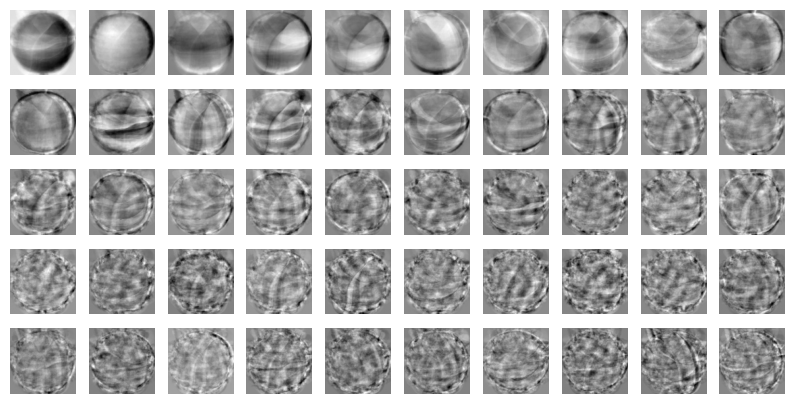

In [ ]:
draw_fruits(pca.components_.reshape(-1, 100, 100))

* 이 주성분은 원본 데이터에서 가장 분산이 큰 방향을 순서대로 나타낸 것.
* 주성분을 찾았으므로 원본 데이터를 주성분에 투영하여 특성의 개수를 10,000개에서 50개로 줄일 수 있음. 이는 마치 원본 데이터를 각 주성분으로 분해하는 것으로 생각할 수 있음.

In [ ]:
print(fruits_2d.shape)

(300, 10000)


In [ ]:
fruits_pca = pca.transform(fruits_2d) # PCA의 transform() 메서드를 사용해 원본 데이터의 차원을 50으로 줄여 보기.
print(fruits_pca.shape)

(300, 50)


* 데이터를 성공적으로 줄였음! 무려 1/200로 줄어들었음.

### 원본 데이터 재구성
* 앞에서 10,000개의 특성을 50개로 줄였음. 이로 인해 어느 정도 손실이 발생할 수밖에 없음. 하지만 최대한 분산이 큰 방향으로 데이터를 투영했기 때문에 원본 데이터를 상당 부분 재구성할 수 있음.

In [ ]:
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

(300, 10000)


* 예상대로 10,000개의 특성이 복원되었음.

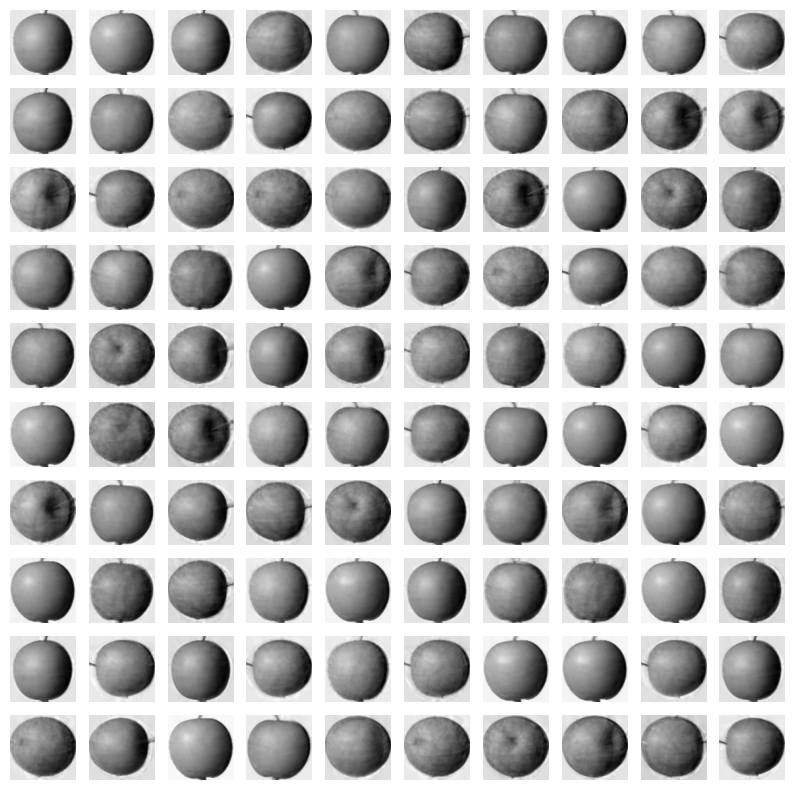

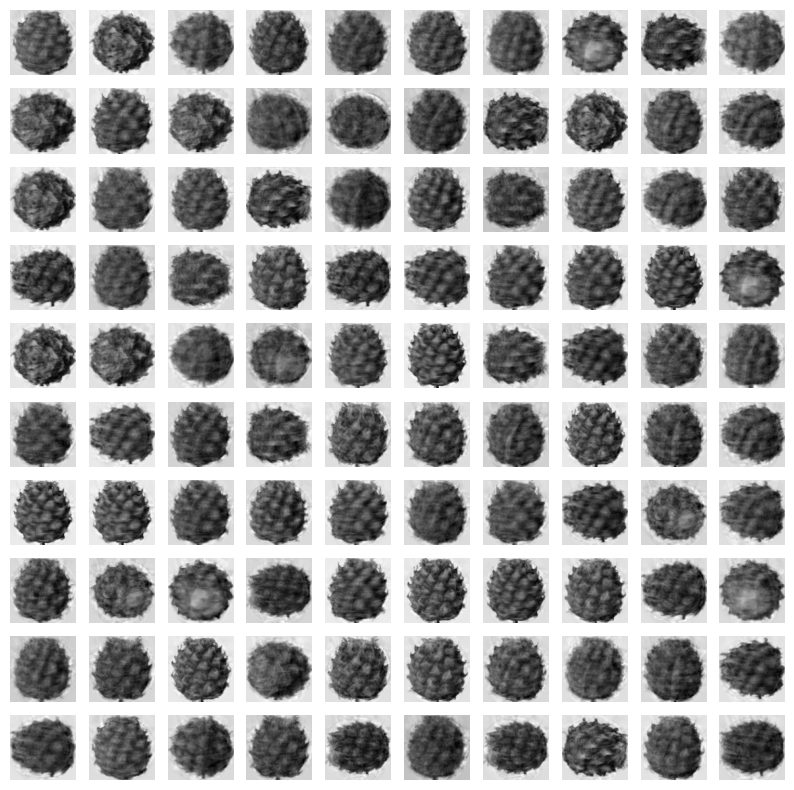

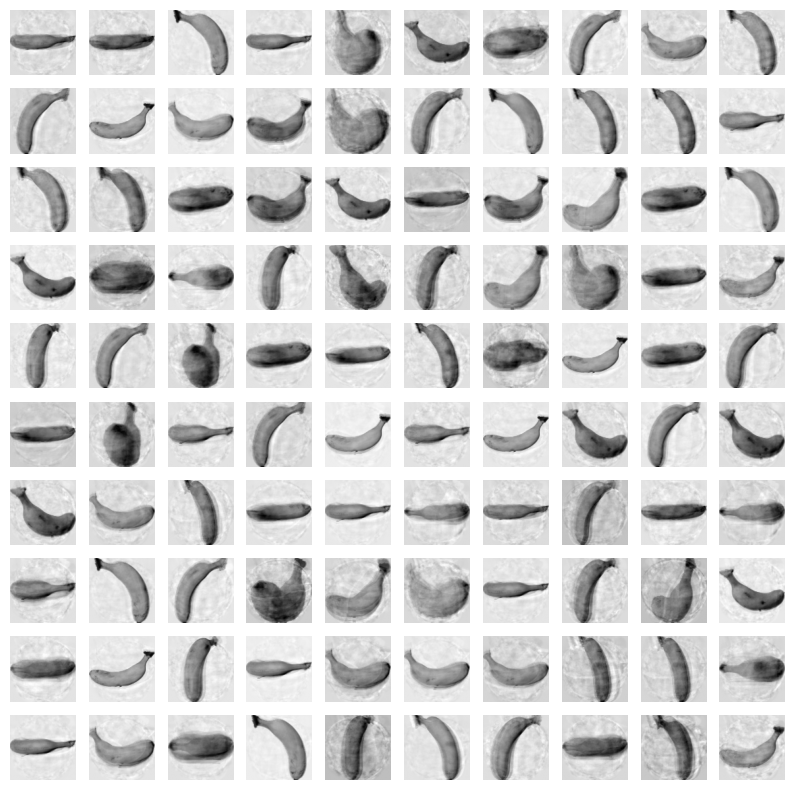

In [ ]:
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)
for start in [0, 100, 200]:
  draw_fruits(fruits_reconstruct[start:start+100])
  print("\n")

* 거의 모든 과일이 잘 복원되었음.
* 만약 주성분을 최대로 사용했다면 완벽하게 원본 데이터를 재구성할 수 있을 것.
* 그럼 50개의 특성은 얼마나 분산을 보존하고 있는 것일까?

### 설명된 분산
* 주성분이 원본 데이터의 분산을 얼마나 잘 나타내는지 기록한 값을 **설명된 분산explained variance**이라고 함. PCA 클래스의 explained_variance_ratio_에 각 주성분의 설명된 분산 비율이 기록되어 있음.
* 이 분산 비율을 모두 더하면 50개의 주성분으로 표현하고 있는 총 분산 비율을 얻을 수 있음.

In [ ]:
print(np.sum(pca.explained_variance_ratio_))

0.9215293863971648


* 92%가 넘는 분산을 유지하고 있음. 앞에서 50개의 특성에서 원본 데이터를 복원했을 때 원본 이미지의 품질이 높았던 이유를 여기에서 찾을 수 있음. 설명된 분산의 비율을 그래프로 그려 보면 적절한 주성분의 개수를 찾는 데 도움이 됨.

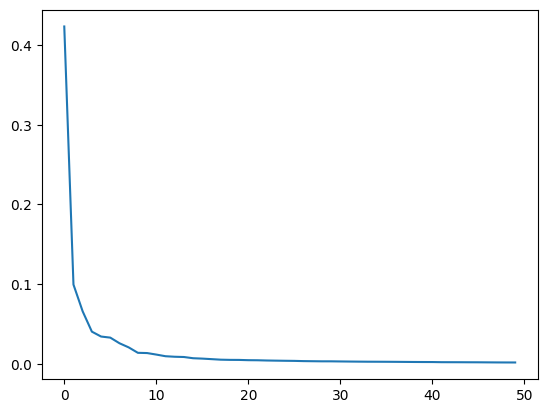

In [ ]:
plt.plot(pca.explained_variance_ratio_)
plt.show()

* 그래프를 보면 처음 10개의 주성분이 대부분의 분산을 표현하고 있음. 그다음부터는 각 주성분이 설명하고 있는 분산은 비교적 작음. 이번에는 PCA로 차원 축소된 데이터를 사용하여 지도 학습 모델을 훈련하겠음.

### 다른 알고리즘과 함께 사용하기

In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

* 지도 학습 모델을 사용하려면 타깃값이 있어야 함. 여기에서는 파인애플을 0, 바나나를 1, 사과를 2로 지정.

In [17]:
target = np.array([0]*100 + [1]*100 + [2]*100)

In [18]:
from sklearn.model_selection import cross_validate
scores = cross_validate(lr, fruits_2d, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
1.8235249042510986


* 교차 검증의 점수는 0.997 정도로 매우 높음. 특성이 10,000개나 되기 때문에 300개의 샘플에서는 금방 과대적합된 모델을 만들기 쉬움.
* cross_validate() 함수가 반환하는 딕셔너리에는 fit_time 항목에 각 교차 검증 폴드의 훈련 시간이 기록되어 있음. 1.82초 정도 걸렸음.

In [19]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.022266435623168945


* 50개의 특성만 사용했는데도 정확도는 동일하고 훈련 시간은 0.02초로 감소. PCA로 훈련 데이터의 차원을 축소하면 저장 공간뿐만 아니라 머신러닝 모델의 훈련 속도도 높일 수 있음.
* 앞서 PCA 클래스를 사용할 때 n_components 매개변수에 주성분의 개수를 지정했음. 이 대신 원하는 설명된 분산의 비율을 입력할 수도 있음. PCA 클래스는 지정된 비율에 도달할 때까지 자동으로 주성분을 찾음.

In [20]:
pca = PCA(n_components=0.5)
pca.fit(fruits_2d)

PCA(n_components=0.5)

In [21]:
print(pca.n_components_)

2


* 단 2개! 2개의 특성만으로 원본 데이터에 있는 분산의 50%를 표현할 수 있음!

In [22]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 2)


* 2개의 특성만 사용하고도 교차 검증의 결과가 좋을까?

In [24]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.99
0.11582612991333008


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


* 2개의 특성을 사용했을 뿐인데 99%의 정확도를 달성.

In [25]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))


* fruits_pca로 찾은 클러스터는 각각 110개, 99개, 91개의 샘플을 포함하고 있음.

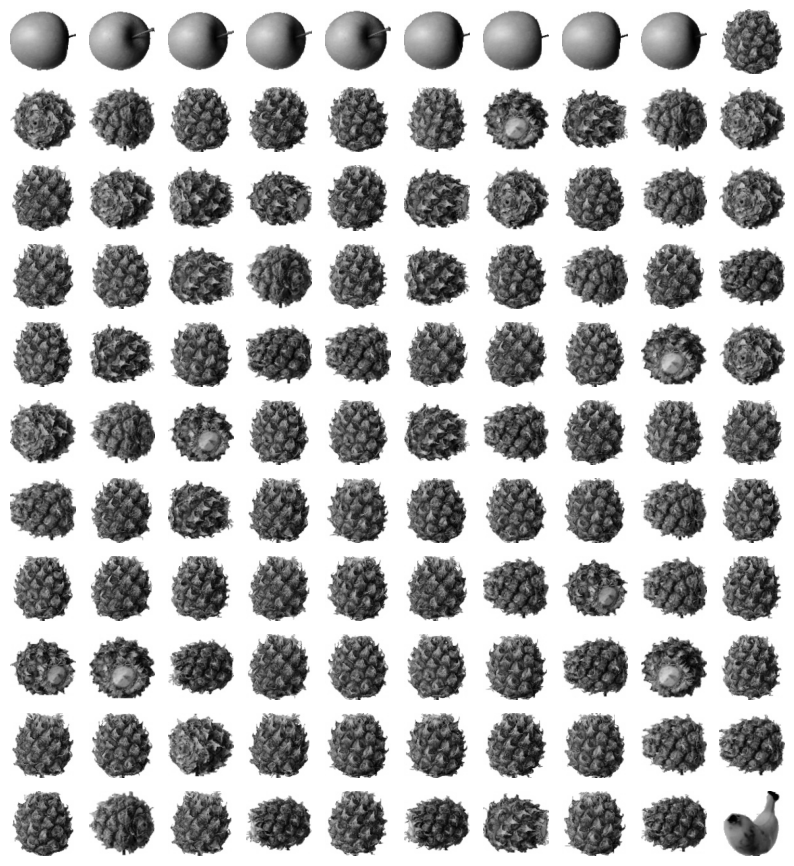

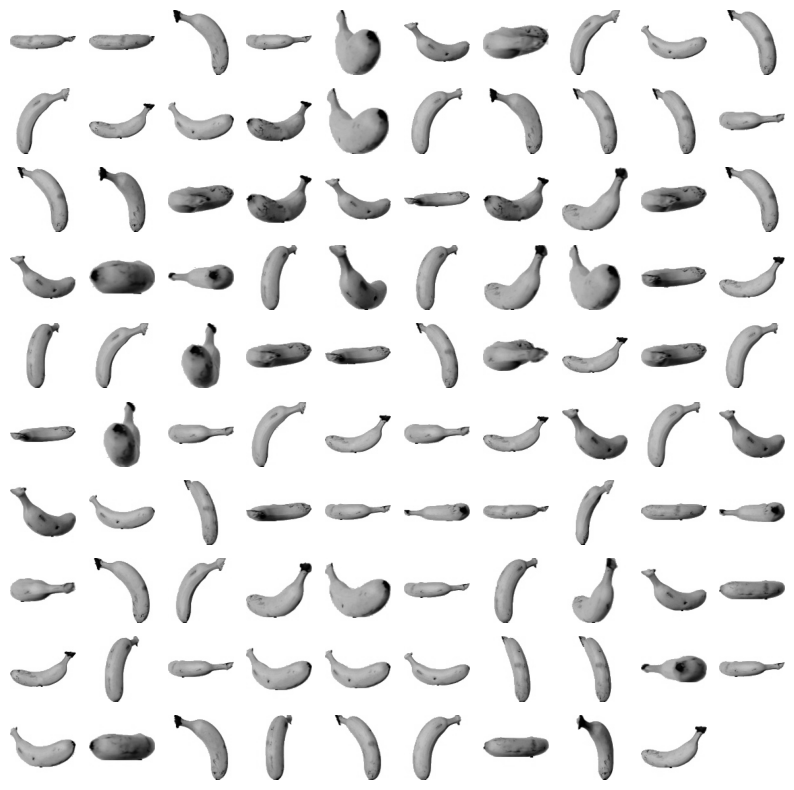

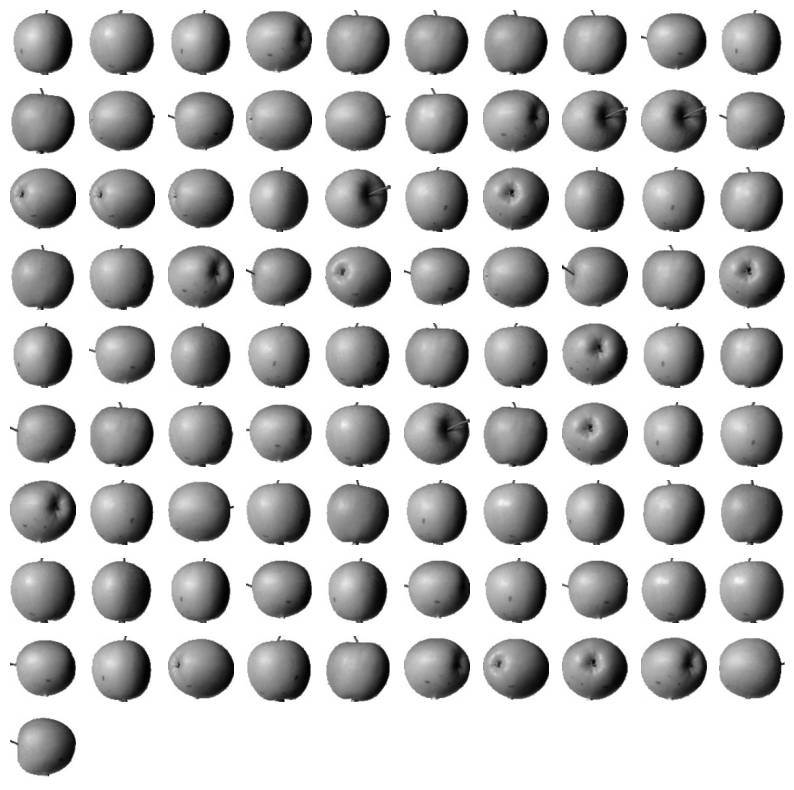

In [26]:
for label in range(0, 3):
  draw_fruits(fruits[km.labels_ == label])
  print("\n")

* 훈련 데이터의 차원을 줄이면 또 하나 얻을 수 있는 장점은 시각화. 3개 이하로 차원을 줄이면 화면에 출력하기 비교적 쉬움.

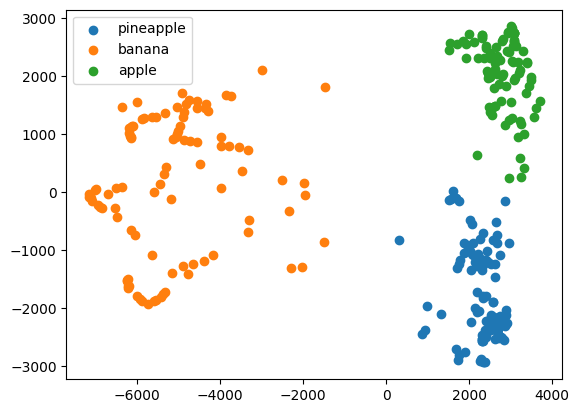

In [28]:
for label in range(0, 3):
  data = fruits_pca[km.labels_ == label]
  plt.scatter(data[:,0], data[:,1])
plt.legend(['pineapple', 'banana', 'apple'])
plt.show()

* 각 클러스터의 산점도가 아주 잘 구분됨! 2개의 특성만을 사용했는데 로지스틱 회귀 모델의 교차 검증 점수가 99%에 달하는 이유를 이제 알 것 같음!
* 이 그림을 보면 사과와 파인애플 클러스터의 경계가 가깝게 붙어 있음. 이 두 클러스터의 샘플은 몇 개가 혼동을 일으키기 쉬울 것 같음. 데이터를 시각화하면 예상치 못한 통찰을 얻을 수 있음.